## TP7: Apprentissage non supervisé

Dans ce TP, nous allons implémenter et comparer deux architectures d'auto-encodeur pour des images du dataset MNIST.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from tqdm.notebook import tqdm

# Import et initialisation de torch
import torch
from torchvision import datasets, transforms
torch.set_num_threads(1)
torch.set_num_interop_threads(1)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

La cellule suivante importe une série de fonctions déjà fournies qui vont vous permettre de visualiser les résultats:
- `load_model`: permet de charger un modèle sauvegardé
- `extract_latents`: utilise l'encodeur d'un auto-encodeur donné pour générer les variables latentes correspondant à un dataloader donné
- `plot_latent`: trace sur une figure les variables latentes
- `plot_reconstructions`: trace sur une figure des images du dataloader et les reconstructions obtenues avec un auto-encodeur donné
- `sample_latent_grid`: trace sur une figure une grille d'images échantillonnées à partir d'un modèle d'auto-encodeur donné
- `make_latent_gif`: génère un gif illustrant l'évolution de l'espace latent d'un auto-encodeur au cours de l'apprentissage

In [2]:
from tp7_utils import load_model, extract_latents, plot_latent, plot_reconstructions, sample_latent_grid, make_latent_gif

## 1. Données

Pendant ce TP, nous allons à nouveau travailler avec le dataset MNIST, qui contient des images de chiffres manuscrits de taille (28, 28).

In [3]:
transform = transforms.Compose([
    transforms.ToTensor()
])

train_dataset = datasets.MNIST(
    root='./data/deep_learning/tp2', train=False, download=False, transform=transform
)
test_dataset = datasets.MNIST(
    root='./data/deep_learning/tp2', train=False, download=False, transform=transform
)

batch_size = 1024

# L'option shuffle=True est importante pour le jeu d'entraînement
# Elle permet de mélanger les données à chaque époque
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

## 1. Définition de l'encodeur et du décodeur

Les auto-encodeurs seront constituées de deux parties:
- l'encodeur: prend en entrée une image $x$ et donne en sortie une représentation latente $z$
- le décodeur: prend en entrée une représentation latente $z$ et donne en sortie une image $\hat{x}$ 

### Question 1.

Complétez la cellule suivante permettant de définir un CNN pour l'encodeur. L'encodeur est constitué de deux couches de convolution et d'une couche linéaire. Des couches de BatchNorm ont aussi été ajoutées.

In [4]:
class CNNEncoder(torch.nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.conv1 = torch.nn.Conv2d(1, 16, kernel_size=4, stride=2, padding=1)  # Convolution avec 16 features de sortie, kernel de taille 4, stride de taille 2 et padding de 1
        self.bn1 = torch.nn.BatchNorm2d(16)  # Batch norm 2d
        self.conv2 = torch.nn.Conv2d(16, 32, kernel_size=4, stride=2, padding=1) # Convolution avec 32 features de sortie, kernel de taille 4, stride de taille 2 et padding de 1
        self.bn2 = torch.nn.BatchNorm2d(32) # Batch norm 2d
        self.fc = torch.nn.Linear(7*7*32, latent_dim) # Couche linéaire avec latent_dim features de sortie, et 7*7*32 features d'entrée
        
    def forward(self, x):
        x = torch.relu(self.bn1(self.conv1(x)))
        x = torch.relu(self.bn2(self.conv2(x)))
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x
        
# Ce code ne doit pas générer d'erreur
encoder = CNNEncoder(latent_dim=16)

### Question 2.

Pour générer une image à partir d'une représentation latente de faible dimension, on peut utiliser des couches de convolutions transposées. En gros, ce sont des couches de convolution qui augmentent la dimension de la feature map en entrée plutôt que de la réduire. Les couches de convolutions transposées vous sont déjà données.

Complétez la définition de la classe `CNNDecoder` représentant un décodeur à base de convolutions transposées.

In [5]:
class CNNDecoder(torch.nn.Module):
    def __init__(self, latent_dim=32):
        super().__init__()
        self.fc = torch.nn.Linear(latent_dim, 7*7*32)   # Couche linéaire avec latent_dim features d'entrée et 7*7*32 features de sortie
        self.bn1= torch.nn.BatchNorm1d(7*7*32) # Batch norm 1d
        self.tconv1 = torch.nn.ConvTranspose2d(32, 16, 4, 2, 1)
        self.bn2 = torch.nn.BatchNorm2d(16) # Batch norm 2d
        self.tconv2 = torch.nn.ConvTranspose2d(16, 1, 4, 2, 1)

    def forward(self, z):
        x = torch.relu(self.bn1(self.fc(z)))
        x = x.view(-1, 32, 7, 7)
        x = torch.relu(self.bn2(self.tconv1(x)))
        x = torch.sigmoid(self.tconv2(x))  # Pour que la sortie soit entre 0 et 1
        return x
        
# Ce code ne doit pas générer d'erreur
decoder = CNNDecoder(latent_dim=16)

## 2. Auto-encodeur classique

Dans un premier temps, nous allons implémenter un auto-encodeur classique. Un auto-encodeur classique se contente de mettre bout à bout un encodeur et un décodeur.

La sortie de l'auto-encodeur est appelée reconstruction, car l'auto-encodeur est entraîné à donner en sortie une image proche de l'image d'entrée.

### Question 3.

Complétez la définition de la classe `AutoEncoder`, en réutilisant les deux classes `CNNEncoder` et `CNNDecoder` définies précédemment.

In [6]:
class AutoEncoder(torch.nn.Module):
    def __init__(self, latent_dim=32):
        super().__init__()
        self.encoder = CNNEncoder(latent_dim)
        self.decoder = CNNDecoder(latent_dim)

    def forward(self, x):
        z = self.encoder(x)
        x_hat = self.decoder(z)
        return x_hat

# Ce code ne doit pas générer d'erreur
ae = AutoEncoder(latent_dim=2)

Nous pouvons maintenant entraîner l'auto-encodeur. La cellule suivante définit des hyperparamètres appropriés pour l'entraînement de l'auto-encodeur.

In [7]:
# Ne pas modifier
latent_dim = 2
lr = 2e-2

# Vous pouvez augmenter le nombre d'époque si vous avez le temps
epochs = 30

### Question 4.

Complétez la cellule suivante permettant d'entraîner l'auto-encodeur.

Lorsqu'on travaille sur des images naturelles, on ne met en général pas de fonction d'activation en sortie du décodeur, et on utilise la Mean Squared Error comme fonction de coût.

Le dataset MNIST fait un peu exception, comme les valeurs des pixels sont de 0 ou 1, on peut interpréter la sortie du décodeur comme une loi de Bernoulli pour chaque pixel donnant la probabilité que le pixel soit à 1. On utilise alors une fonction d'activation sigmoid en sortie du décodeur (pour que les valeurs soient entre 0 et 1) et la Binary Cross Entropy comme fonction de coût.

In [9]:
import os

# Crée le dossier 'checkpoints' s'il n'existe pas déjà
os.makedirs("checkpoints", exist_ok=True)

In [10]:
ae = AutoEncoder(latent_dim=latent_dim)
ae = ae.to(device)

train_loss = []
test_loss = []

optimizer = torch.optim.Adam(ae.parameters(), lr=lr)
loss_fn = torch.nn.BCELoss() # Binary Cross Entropy

for epoch in tqdm(range(epochs)):

    # ============= Phase d'entraînement ============
    ae.train()  # On met le modèle en mode entraînement (utile pour dropout/batchnorm)

    epoch_train_loss = 0.0  # Pour accumuler la loss sur l'époque
    total = 0  # Pour accumuler le nombre d'exemples vus

    # On itère sur tous les batchs du jeu d'entraînement
    for images, _ in train_loader:
        images = images.to(device)
        
        # On met les gradients à zéro avant la rétro-propagation
        optimizer.zero_grad()

        # Passe forward dans le réseau de neurone et la fonction de coût
        x_hat = ae(images)
        loss = loss_fn(x_hat, images)

        # On sauvegarde les statistiques
        epoch_train_loss += loss.item() * images.size(0)
        total += images.size(0)

        # Rétro-propagation et mise à jour des poids
        loss.backward()
        optimizer.step()

    # On sauvegarde la loss et l'accuracy de l'époque
    epoch_loss = epoch_train_loss / total
    train_loss.append(epoch_loss)

    # ============= Phase d'évaluation ============
    ae.eval()  # On met le modèle en mode évaluation (utile pour dropout/batchnorm)
    epoch_test_loss = 0.0
    total = 0

    with torch.no_grad():  # Pas besoin de calculer les gradients en évaluation
        for images, _ in test_loader:
            images = images.to(device)
            
            # On met les gradients à zéro avant la rétro-propagation
            optimizer.zero_grad()
    
            # Passe forward dans le réseau de neurone et la fonction de coût
            x_hat = ae(images)
            loss = loss_fn(x_hat, images)
            epoch_test_loss += loss.item() * images.size(0)
            total += images.size(0)

    torch.save(ae.state_dict(), f"checkpoints/ae_epoch_{epoch}.pt")
    
    epoch_loss = epoch_test_loss / total
    test_loss.append(epoch_loss)

  0%|          | 0/30 [00:00<?, ?it/s]

Les cellules suivantes permettent d'afficher:
- L'évolution de la fonction de coût pendant l'entraînement
- Des exemples de reconstructions obenues après entraînement
- L'évolution des représentations latentes pendant l'entraînement


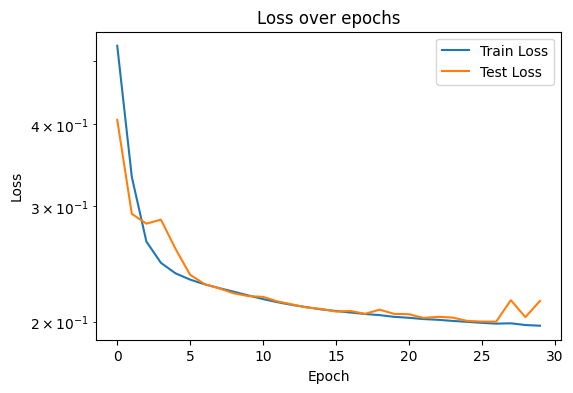

In [11]:
plt.figure(figsize=(6, 4))
plt.plot(train_loss, label='Train Loss')
plt.plot(test_loss, label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.yscale('log')
plt.title('Loss over epochs')
plt.legend()
plt.show()

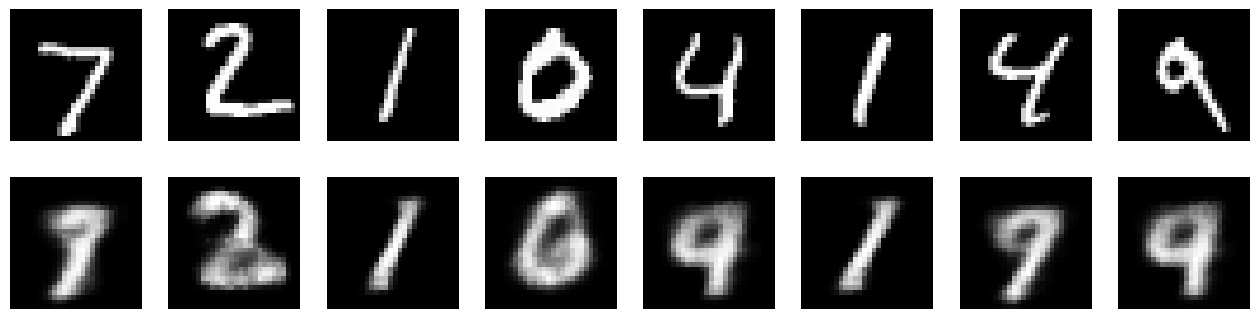

In [12]:
plot_reconstructions(ae, test_loader)

La cellule suivante permet de générer un gif représentant l'évolution de l'espace latent au cours de l'entraînement. Chaque image du gif représente les valeurs de $z$ en deux dimensions, obtenues après passage dans l'encodeur, pour chaque époque d'entraînement (15 époques donc 15 frames dans le gif).

De plus, on représente chaque point $z$ avec la couleur correspondant au label de l'image (le chiffre entre 0 et 9 correspondant à l'image). Attention: l'auto-encodeur n'a pas cette information à sa disposition.

In [13]:
make_latent_gif(
    model_class=AutoEncoder,
    checkpoints="ae",
    dataloader=test_loader,
    latent_dim=latent_dim,
    device=device,
    out_path="ae_latent_training.gif",
    fps=4,
    epochs=epochs,
    limit=30
)

Saved GIF → ae_latent_training.gif


La cellule suivante en Markdown permet de visualiser dans le notebook le gif généré par la cellule précédente. Si vous regénérer le gif, ça ne se met pas à jour automatiquement. Vous pouvez aussi visualiser le gif directement dans vos fichiers à gauche.

![AE_GIF](ae_latent_training.gif "Auto Encoder")

### Question 5.

A débriefer à l'oral avec votre chargé.e de TP:
- Commentez les résutlats (les reconstructions et le gif), que remarquez-vous ?
- Est-il possible d'échantilloner des chiffres à partir du décodeur obtenu ?

## 3. Variational Auto-Encoder (VAE)

Dans cette partie, nous allons définir et entraîner un VAE.

Le VAE est une extension de l'auto-encodeur classique qui permet d'apprendre un modèle génératif $p(x)$ des images formant le dataset. 
- Le décodeur du VAE est exactement identique à celui de l'auto-encodeur classique.
- En revanche, l'encodeur ne donne pas directement une valeur pour $z$, mais les paramètres $\mu$ et $\sigma^2$ d'une loi gaussienne $\mathcal N(\mu, \sigma^2)$ donnant la probabilité de $z$. $\mu$ et $\sigma^2$ sont tous les deux des vecteurs de dimension `latent_dim`. En pratique, l'encodeur donne en sortie une variable `mu` correspondant à $\mu$ et une variable `logvar` correspondant à $\log \sigma^2$. Prédire $\log \sigma^2$ plutôt que $\sigma^2$ améliore la stabilité numérique dans les calculs de fonction de coût (voir la fonction `kl_loss` un peu plus loin).
- La valeur de `z` donnée en entrée du décodeur est échantillonée à partir de `mu` et `logvar`, en utilisant ce qu'on appelle le reparameterization trick: $z = \mu + \sigma \epsilon$ avec $\epsilon \sim \mathcal N (0, 1)$


### Question 6.

Complétez la définition de la classe `VAE`:

In [14]:
class VAE(torch.nn.Module):
    def __init__(self, latent_dim=32):
        super().__init__()
        self.latent_dim = latent_dim
        self.encoder = CNNEncoder(latent_dim*2)
        self.decoder = CNNDecoder(latent_dim)

    def encode(self, x):
        x = self.encoder(x)
        mu = x[:, :self.latent_dim]
        logvar = x[:, self.latent_dim:]
        return mu, logvar

    def decode(self, z):
        return self.decoder(z)
        
    def reparameterize(self, mu, logvar):
        # Calcul de sigma à partir de logvar
        sigma = torch.exp(0.5 * logvar)

        # Echantillonage de epsilon
        eps = torch.randn_like(sigma)
        
        # Reparameterization trick
        z = mu + sigma * eps
        
        return z

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        x_hat = self.decode(z)
        return x_hat, mu, logvar  # On a besoin de retourner également mu et logvar pour le calcul de la kl_loss

L'entraînement du VAE va chercher à minimiser une fonction de coût composée de deux termes: $\mathcal L  = \mathcal L_{reco} + \beta \mathcal{L}_{KL}$

- Le terme $\mathcal L_{reco}$ est la loss de reconstruction, c'est la même que celle utilisée dans l'auto-encodeur classique. Minimiser cette loss revient à améliorer la qualité de la reconstruction.
- Le terme $\mathcal L_{KL}$ est la divergence de Kullback Leibler entre la loi normale $\mathcal N(0, 1)$ et la loi prédite par l'encodeur $\mathcal N(\mu, \sigma^2)$. La divergence de Kullback Leibler entre deux lois de probabilité est nulle lorsque ces deux lois sont égales. Minimiser cette fonction de coût revient donc à forcer l'encodeur à produire une distribution proche de $\mathcal{N}(0, 1)$.
- Le coefficient $\beta$ est un hyperparamètre qui sert à pondérer la deuxième fonction de coût. Si $\beta$ est trop grand, la loss de KL prend le dessus et l'encodeur converge vers une prédiction où $\mu = 0$ et $\sigma^2 = 1$. La reconstruction est alors forcément très mauvaise. Si $\beta$ est trop petit, le deuxième terme de la fonction de coût n'a presque aucun impact, et on retombe sur un auto-encodeur classique.

La cellule ci-dessous définit la fonction `kl_loss` permettant de calculer $\mathcal L_{KL}$.

In [15]:
def kl_loss(mu, logvar):
    return -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

La cellule suivante définit des valeurs d'hyperparamètres qui fonctionne assez bien, il n'est pas nécessaire de les changer.

In [16]:
# Ne pas changer
latent_dim = 2
beta = 1e-5
lr = 1e-3

# Vous pouvez augmenter le nombre d'époque si vous avez le temps
epochs = 30

### Question 7.

Complétez la cellule suivante permettant d'entraîner un VAE:

In [17]:
vae = VAE(latent_dim=latent_dim)
vae = vae.to(device)

train_loss = []
test_loss = []

optimizer = torch.optim.Adam(vae.parameters(), lr=lr)
loss_fn = torch.nn.BCELoss()

for epoch in tqdm(range(epochs)):

    # ============= Phase d'entraînement ============
    vae.train()  # On met le modèle en mode entraînement (utile pour dropout/batchnorm)

    epoch_train_loss = 0.0  # Pour accumuler la loss sur l'époque
    total = 0  # Pour accumuler le nombre d'exemples vus

    # On itère sur tous les batchs du jeu d'entraînement
    for images, _ in train_loader:
        images = images.to(device)
        
        # On met les gradients à zéro avant la rétro-propagation
        optimizer.zero_grad()

        # Passe forward dans le réseau de neurones
        x_hat, mu, logvar = vae(images)
        
        # Calcul des deux composantes de la fonction de coût
        loss_reco = loss_fn(x_hat, images)
        loss_kl = kl_loss(mu, logvar)
        
        # Coût total
        loss = loss_reco + beta * loss_kl
        
        # On sauvegarde les statistiques
        epoch_train_loss += loss.item() * images.size(0)
        total += images.size(0)

        # Rétro-propagation et mise à jour des poids
        loss.backward()
        optimizer.step()

    # On sauvegarde la loss et l'accuracy de l'époque
    epoch_loss = epoch_train_loss / total
    train_loss.append(epoch_loss)

    # ============= Phase d'évaluation ============
    ae.eval()  # On met le modèle en mode évaluation (utile pour dropout/batchnorm)
    epoch_test_loss = 0.0
    total = 0

    with torch.no_grad():  # Pas besoin de calculer les gradients en évaluation
        for images, _ in test_loader:
            images = images.to(device)
            
            # On met les gradients à zéro avant la rétro-propagation
            optimizer.zero_grad()
    
            # Passe forward dans le réseau de neurones
            x_hat, mu, logvar = vae(images)
            
            # Calcul des deux composantes de la fonction de coût
            loss_reco = loss_fn(x_hat, images)
            loss_kl = kl_loss(mu, logvar)
            
            # Coût total
            loss = loss_reco + beta * loss_kl
            
            epoch_test_loss += loss.item() * images.size(0)
            total += images.size(0)

    torch.save(vae.state_dict(), f"checkpoints/vae_epoch_{epoch}.pt")
    
    epoch_loss = epoch_test_loss / total
    test_loss.append(epoch_loss)

  0%|          | 0/30 [00:00<?, ?it/s]

Les cellules suivantes permettent d'afficher:
- L'évolution de la fonction de coût pendant l'entraînement
- Des exemples de reconstructions obenues après entraînement
- L'évolution des représentations latentes pendant l'entraînement

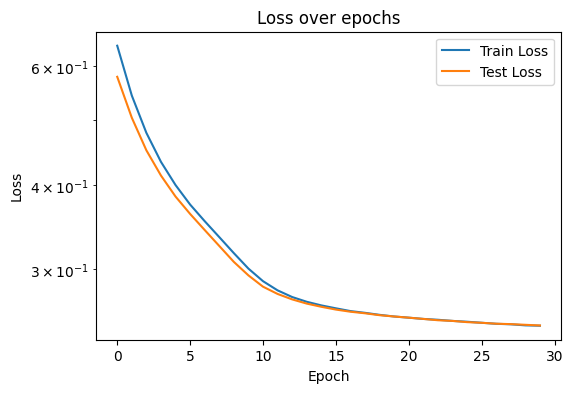

In [18]:
plt.figure(figsize=(6, 4))
plt.plot(train_loss, label='Train Loss')
plt.plot(test_loss, label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.yscale('log')
plt.title('Loss over epochs')
plt.legend()
plt.show()

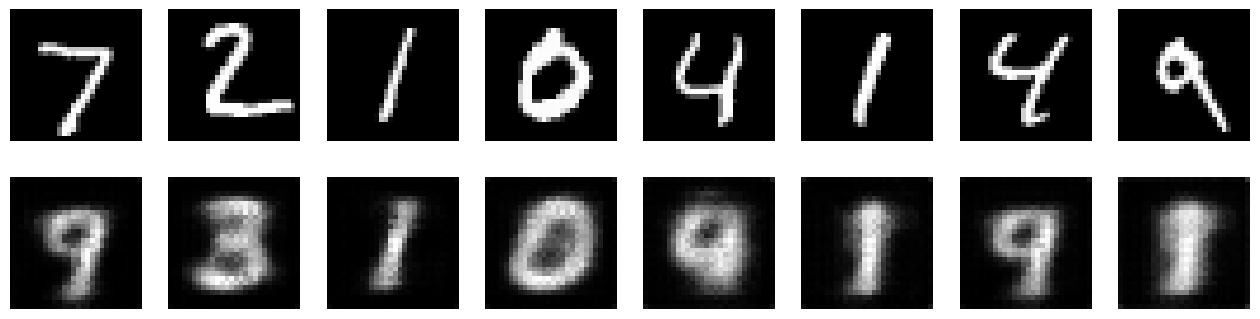

In [19]:
plot_reconstructions(vae, test_loader)

In [ ]:
make_latent_gif(
    model_class=VAE,      # or Autoencoder
    checkpoints="vae",
    dataloader=test_loader,
    latent_dim=latent_dim,
    device=device,
    out_path="vae_latent_training.gif",
    fps=4,
    epochs=epochs,
    limit=3
)

Double cliquez cette cellule et relancez la pour faire apparaître le gif.

![VAE_GIF](vae_latent_training.gif "Variational Auto Encoder")

### Question 8.

A débriefer à l'oral avec votre chargé.e de TP:
- Qu'observez-vous sur ce gif en comparaison avec l'auto-encdeur classique étudié dans la première partie ?
- Est-il possible d'échantilloner des chiffres à partir du décodeur obtenu ?

## 4. Génération

La fonction de coût du VAE correspond en fait (en vous épargnant les preuves) à une borne supérieure de $\mathcal L^* = - \log p_\theta(x)$. En minimisant la fonction de coût, on a également maximisé la probabilité $p_\theta(x)$. Attention, dans cette formule, $p_\theta(x)$ n'est pas la vraie distribution des images $x$, ni celle du dataset, mais une distribution apprise à partir des données.

Il est possible de générer des échantillons de cette distribution de probabilité directement en échantillonant $z\sim \mathcal N(0, 1)$ puis en passant $z$ dans le décodeur.

Dans la cellule suivante, on génère une grille de valeurs pour $z$ dans l'intervalle $[-2, 2] \times [-2, 2]$ de l'espace latent, et on les passe dans le décodeur pour générer les images correspondantes.

In [ ]:
sample_latent_grid(vae)

### Question 9.

A débriefer avec votre chargé.e de TP.

Comparez cette grille à la dernière distribution de l'espace latent (dernière frame du gif), qu'observez-vous ?